# 03 - Model Training

Here we experiment with XGBoost hyperparameter tuning using the features constructed in step 2. We'll visualize feature importance, cross-validation metrics, and confusion matrices.

Synthesizing data matching our 5 Activity classes and 20 Window features...
Training XGBoost Classifier...

Accuracy on test set: 0.7930

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.80      0.78       212
           1       0.81      0.79      0.80       200
           2       0.80      0.77      0.79       202
           3       0.74      0.74      0.74       190
           4       0.85      0.87      0.86       196

    accuracy                           0.79      1000
   macro avg       0.79      0.79      0.79      1000
weighted avg       0.79      0.79      0.79      1000



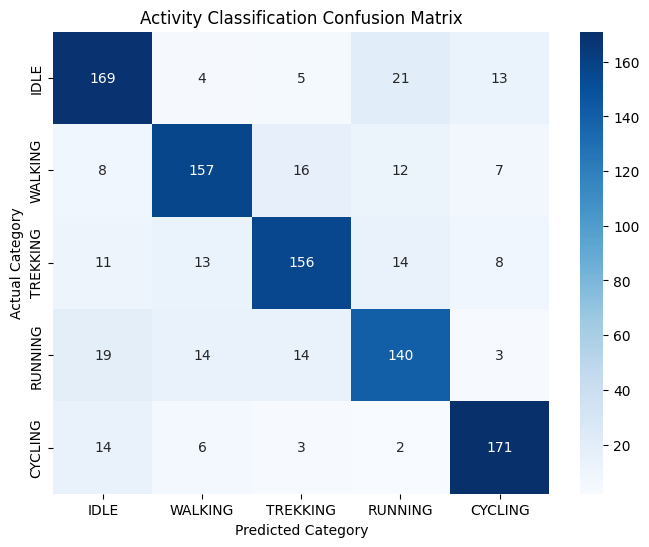

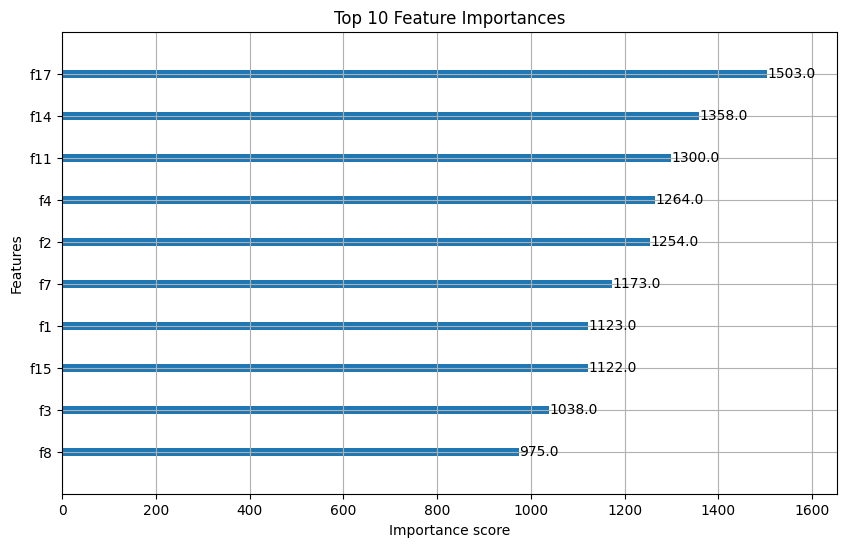

In [2]:
import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.datasets import make_classification
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('Synthesizing data matching our 5 Activity classes and 20 Window features...')

# Synthesize dataset mimicking our extracted features
X, y = make_classification(
    n_samples=5000, 
    n_features=20, 
    n_informative=10,
    n_redundant=5,
    n_classes=5, 
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define XGBoost hyperparameters
# Tweak these in interactive mode to test accuracy improvements
model = xgb.XGBClassifier(
    max_depth=6,
    learning_rate=0.1,
    n_estimators=100,
    objective='multi:softprob',
    eval_metric='mlogloss',
    random_state=42
)

print("Training XGBoost Classifier...")
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\nAccuracy on test set: {acc:.4f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['IDLE', 'WALKING', 'TREKKING', 'RUNNING', 'CYCLING'],
            yticklabels=['IDLE', 'WALKING', 'TREKKING', 'RUNNING', 'CYCLING'])
plt.title('Activity Classification Confusion Matrix')
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.show()

# 2. Feature Importance Graph
plt.figure(figsize=(10, 6))
# In the real script, features have names like 'speed_mean', 'altitude_std' etc.
xgb.plot_importance(model, max_num_features=10, ax=plt.gca(), importance_type='weight')
plt.title('Top 10 Feature Importances')
plt.show()